In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt



def load_transfer_entropy_matrix(excelFilePath):
    """
    Load transfer entropy data from Excel file and convert to matrix format.
    Parses TE values from 'mean ± std' format and creates adjacency matrix.
    
    Parameters:
    -----------
    excelFilePath : str
        Path to the transfer entropy Excel file
    
    Returns:
    --------
    matrixDf : pandas.DataFrame
        Transfer entropy matrix with electrodes as index/columns
    """
    df = pd.read_excel(excelFilePath)
    print(f"Loaded data shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    def parse_te_value(valueStr):
        if pd.isna(valueStr):
            return 0.0
        try:
            meanVal = float(str(valueStr).split('±')[0].strip())
            return meanVal
        except:
            return 0.0
    teColumn = 'Avg TE (without gaussian noise)'
    pairColumn = 'Pair name'
    if teColumn not in df.columns:
        teCols = [col for col in df.columns if 'TE' in col and 'noise' in col]
        if teCols:
            teColumn = teCols[0]
            print(f"Using TE column: {teColumn}")
        else:
            print("Available columns:", df.columns.tolist())
            raise ValueError("Could not find transfer entropy column")
    if pairColumn not in df.columns:
        pairCols = [col for col in df.columns if 'pair' in col.lower() or 'name' in col.lower()]
        if pairCols:
            pairColumn = pairCols[0]
            print(f"Using pair column: {pairColumn}")
    teValues = df[teColumn].apply(parse_te_value)
    sources = []
    targets = []
    for pair in df[pairColumn]:
        if '->' in str(pair):
            source, target = str(pair).split('->')
            sources.append(source.strip())
            targets.append(target.strip())
        else:
            sources.append('Unknown')
            targets.append('Unknown')
    teDf = pd.DataFrame({
        'source': sources,
        'target': targets,
        'te_value': teValues
    })
    allElectrodes = sorted(list(set(sources + targets)))
    allElectrodes = [e for e in allElectrodes if e != 'Unknown']
    print(f"Found {len(allElectrodes)} unique electrodes: {allElectrodes}")
    nElectrodes = len(allElectrodes)
    matrix = np.zeros((nElectrodes, nElectrodes))
    electrodeToIdx = {electrode: idx for idx, electrode in enumerate(allElectrodes)}
    for _, row in teDf.iterrows():
        if row['source'] in electrodeToIdx and row['target'] in electrodeToIdx:
            srcIdx = electrodeToIdx[row['source']]
            tgtIdx = electrodeToIdx[row['target']]
            matrix[srcIdx, tgtIdx] = row['te_value']
    matrixDf = pd.DataFrame(matrix, index=allElectrodes, columns=allElectrodes)
    print(f"Matrix shape: {matrixDf.shape}")
    print(f"Non-zero values: {(matrixDf > 0).sum().sum()}")
    print(f"TE value range: {matrixDf.values[matrixDf.values > 0].min():.4f} - {matrixDf.values.max():.4f}")
    return matrixDf


def analyze_connections(connections, plotType=""):
    """
    Analyze and print connection statistics including sources, targets, and strongest connections.
    
    Parameters:
    -----------
    connections : list
        List of (source, target, te_value) tuples
    plotType : str
        Type of plot for labeling output
    """
    print(f"\n{plotType.upper()} ANALYSIS:")
    print("="*70)
    sources = {}
    targets = {}
    for source, target, teVal in connections:
        sources[source] = sources.get(source, 0) + 1
        targets[target] = targets.get(target, 0) + 1
    print(f"TOP INFORMATION SOURCES (outgoing):")
    for electrode, count in sorted(sources.items(), key=lambda x: x[1], reverse=True)[:5]:
        inCount = targets.get(electrode, 0)
        print(f"   {electrode}: {count} out, {inCount} in")
    print(f"\nTOP INFORMATION TARGETS (incoming):")
    for electrode, count in sorted(targets.items(), key=lambda x: x[1], reverse=True)[:5]:
        outCount = sources.get(electrode, 0)
        print(f"   {electrode}: {count} in, {outCount} out")
    print(f"\nTOP 10 STRONGEST CONNECTIONS:")
    for i, (source, target, teVal) in enumerate(connections[:10]):
        print(f"{i+1:2d}. {source:>3} -> {target:<3}: {teVal:.4f}")

In [ ]:
def create_te_circular_plot(matrixDf, thresholdPercentile=80, figsize=(14, 14), titleSuffix="", 
                           showTopN=None, removeNodeOutline=False, colorScaleMin=None, colorScaleMax=None,
                           labelDistance=1.15, lineWidthScale=1.0, colormap='plasma', invertColors=False):
    """
    Create circular plot showing transfer entropy connections with electrodes arranged in circle.
    Filters connections by percentile threshold or shows top N connections with proper color mapping.
    
    Parameters:
    -----------
    matrixDf : pandas.DataFrame
        Transfer entropy matrix with electrodes as index/columns
    thresholdPercentile : int
        Percentage threshold for filtering connections (default: 80)
    figsize : tuple
        Figure size (default: (14, 14))
    titleSuffix : str
        Additional text for plot title
    showTopN : int or None
        If provided, show only top N connections instead of percentile threshold
    removeNodeOutline : bool
        If True, remove black outline from electrode nodes
    colorScaleMin : float or None
        Minimum value for color scale (if None, uses actual min TE value)
    colorScaleMax : float or None
        Maximum value for color scale (if None, uses actual max TE value)
    labelDistance : float
        Distance multiplier for electrode labels from center (default: 1.15)
        1.0 = on the circle, 1.15 = 15% outside, 1.3 = 30% outside
    lineWidthScale : float
        Scaling factor for connection line widths (default: 1.0)
        0.5 = thinner lines, 2.0 = thicker lines
    colormap : str
        Matplotlib colormap name (default: 'plasma')
        Options: 'plasma', 'viridis', 'inferno', 'magma', 'cividis', 'jet', 'coolwarm', etc.
    invertColors : bool
        If True, invert the colormap (default: False)
        When False: weak=dark, strong=bright (normal)
        When True: weak=bright, strong=dark (inverted)
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    connections : list
        List of (source, target, te_value) tuples
    """
    electrodes = matrixDf.index.tolist()
    nElectrodes = len(electrodes)
    angles = np.linspace(0, 2*np.pi, nElectrodes, endpoint=False)
    radius = 5
    positions = {}
    for i, electrode in enumerate(electrodes):
        x = radius * np.cos(angles[i])
        y = radius * np.sin(angles[i])
        positions[electrode] = (x, y)
    connections = []
    for i, source in enumerate(matrixDf.index):
        for j, target in enumerate(matrixDf.columns):
            teValue = matrixDf.iloc[i, j]
            if teValue > 0:
                connections.append((source, target, teValue))
    connections.sort(key=lambda x: x[2], reverse=True)
    if showTopN is not None:
        connections = connections[:showTopN]
        titleExtra = f"Top {showTopN} Connections"
    else:
        threshold = np.percentile(matrixDf.values[matrixDf.values > 0], thresholdPercentile)
        connections = [conn for conn in connections if conn[2] >= threshold]
        titleExtra = f"Top {100-thresholdPercentile}%"
    fig, ax = plt.subplots(figsize=figsize)
    nodeOutlineColor = 'none' if removeNodeOutline else 'black'
    nodeLineWidth = 0 if removeNodeOutline else 2
    
    # Draw electrode nodes FIRST (bottom layer)
    for electrode, (x, y) in positions.items():
        ax.scatter(x, y, s=800, c='lightblue', alpha=0.8, 
                  edgecolors=nodeOutlineColor, linewidth=nodeLineWidth, zorder=1)
    
    actualMinTe = min([conn[2] for conn in connections])
    actualMaxTe = max([conn[2] for conn in connections])
    colorMinTe = colorScaleMin if colorScaleMin is not None else actualMinTe
    colorMaxTe = colorScaleMax if colorScaleMax is not None else actualMaxTe
    print(f"Actual TE range: {actualMinTe:.4f} - {actualMaxTe:.4f}")
    print(f"Color scale range: {colorMinTe:.4f} - {colorMaxTe:.4f}")
    print(f"Line width scale factor: {lineWidthScale}")
    print(f"Colormap: {colormap} (inverted: {invertColors})")
    
    # Choose colormap with optional inversion
    if invertColors:
        cmap_name = f"{colormap}_r"
    else:
        cmap_name = colormap
    
    cmap = plt.cm.get_cmap(cmap_name)
    
    # REVERSE the order: draw weakest connections first, strongest last (middle layer)
    connections_reversed = connections[::-1]  # Reverse the list
    for i, (source, target, teValue) in enumerate(connections_reversed):
        x1, y1 = positions[source]
        x2, y2 = positions[target]
        colorValue = (teValue - colorMinTe) / (colorMaxTe - colorMinTe)
        colorValue = max(0, min(1, colorValue))
        connectionColor = cmap(colorValue)
        
        # Apply line width scaling factor
        baseLineWidth = 1 + 8 * (teValue - actualMinTe) / (actualMaxTe - actualMinTe)
        lineWidth = baseLineWidth * lineWidthScale
        
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle='->', lw=lineWidth, 
                                 color=connectionColor, alpha=0.7,
                                 connectionstyle="arc3,rad=0.1"),
                   zorder=5)
    
    # Add electrode labels OUTSIDE the circle - configurable distance (top layer)
    labelRadius = radius * labelDistance
    for i, electrode in enumerate(electrodes):
        angle = angles[i]
        labelX = labelRadius * np.cos(angle)
        labelY = labelRadius * np.sin(angle)
        
        # Adjust text alignment based on position
        if labelX > 0.1:
            ha = 'left'
        elif labelX < -0.1:
            ha = 'right'
        else:
            ha = 'center'
            
        if labelY > 0.1:
            va = 'bottom'
        elif labelY < -0.1:
            va = 'top'
        else:
            va = 'center'
        
        ax.text(labelX, labelY, electrode, fontsize=12, fontweight='bold',
               ha=ha, va=va, color='black', zorder=15)
    
    # Adjust plot limits based on label distance
    plotLimit = max(8, labelRadius + 1)
    ax.set_xlim(-plotLimit, plotLimit)
    ax.set_ylim(-plotLimit, plotLimit)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'Transfer Entropy Connections ({titleExtra})\n{titleSuffix}\n{len(connections)} connections shown', 
                fontsize=16, fontweight='bold', pad=20)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=colorMinTe, vmax=colorMaxTe))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.8, pad=0.1)
    cbar.set_label('Transfer Entropy Strength', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    return fig, connections


def create_chord_with_huge_straight_arrows(matrixDf, topN=15, figsize=(12, 12), titleSuffix=""):
    """
    Create chord plot with huge straight arrows showing top N connections.
    Features large arrows, role-based node coloring (source/target/hub), and connection counts.
    
    Parameters:
    -----------
    matrixDf : pandas.DataFrame
        Transfer entropy matrix with electrodes as index/columns
    topN : int
        Number of top connections to show (default: 15)
    figsize : tuple
        Figure size (default: (12, 12))
    titleSuffix : str
        Additional text for plot title
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    topConnections : list
        List of (source, target, te_value) tuples for top connections
    """
    connections = []
    for i, source in enumerate(matrixDf.index):
        for j, target in enumerate(matrixDf.columns):
            teValue = matrixDf.iloc[i, j]
            if teValue > 0:
                connections.append((source, target, teValue))
    connections.sort(key=lambda x: x[2], reverse=True)
    topConnections = connections[:topN]
    electrodesInTop = set()
    for source, target, _ in topConnections:
        electrodesInTop.add(source)
        electrodesInTop.add(target)
    electrodes = sorted(list(electrodesInTop))
    nElectrodes = len(electrodes)
    print(f"Creating chord plot with {len(topConnections)} connections and HUGE STRAIGHT arrows")
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor('white')
    angles = np.linspace(0, 2*np.pi, nElectrodes, endpoint=False)
    radius = 1.0
    positions = {}
    for i, electrode in enumerate(electrodes):
        x = radius * np.cos(angles[i])
        y = radius * np.sin(angles[i])
        positions[electrode] = (x, y)
    minTe = min([c[2] for c in topConnections])
    maxTe = max([c[2] for c in topConnections])
    colors = plt.cm.viridis(np.linspace(0, 1, len(topConnections)))
    for i, (source, target, teValue) in enumerate(topConnections):
        if source in positions and target in positions:
            x1, y1 = positions[source]
            x2, y2 = positions[target]
            normalizedStrength = (teValue - minTe) / (maxTe - minTe)
            lineWidth = 4 + 8 * normalizedStrength
            ax.plot([x1, x2], [y1, y2], 
                   color=colors[i], linewidth=lineWidth, alpha=0.7, zorder=3)
            # -- STEP 1: Calculate arrow position
            arrowPos = 0.75
            arrowX = x1 + arrowPos * (x2 - x1)
            arrowY = y1 + arrowPos * (y2 - y1)
            # -- STEP 2: Calculate direction vector
            dx = x2 - x1
            dy = y2 - y1
            length = np.sqrt(dx**2 + dy**2)
            if length > 0:
                arrowScale = 0.15
                arrowDx = (dx / length) * arrowScale
                arrowDy = (dy / length) * arrowScale
                ax.quiver(arrowX, arrowY, arrowDx, arrowDy, 
                         color=colors[i], scale=1, scale_units='xy', angles='xy',
                         width=lineWidth/800, headwidth=8, headlength=4, 
                         headaxislength=3, alpha=0.9, zorder=5)
            # -- STEP 3: Add strength label
            midX, midY = (x1 + x2) / 2, (y1 + y2) / 2
            offsetX = midX + 0.1 * (midY)
            offsetY = midY - 0.1 * (midX)
            ax.text(offsetX, offsetY, f'{teValue:.3f}', 
                   fontsize=10, fontweight='bold',
                   ha='center', va='center',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor='white', 
                           edgecolor=colors[i], linewidth=2, alpha=0.95),
                   zorder=6)
    # -- STEP 4: Draw electrode nodes with role-based coloring
    for electrode, (x, y) in positions.items():
        inCount = sum(1 for s, t, _ in topConnections if t == electrode)
        outCount = sum(1 for s, t, _ in topConnections if s == electrode)
        totalCount = inCount + outCount
        nodeSize = 400 + totalCount * 100
        if outCount > inCount:
            nodeColor = 'orange'
            role = 'SOURCE'
        elif inCount > outCount:
            nodeColor = 'lightgreen'
            role = 'TARGET'
        else:
            nodeColor = 'lightblue'
            role = 'HUB'
        ax.scatter(x, y, s=nodeSize, c=nodeColor, 
                  edgecolors='black', linewidth=4, zorder=10)
        ax.text(x, y, electrode, fontsize=14, fontweight='bold',
               ha='center', va='center', color='black', zorder=11)
        ax.text(x*1.4, y*1.4, f'{electrode}\n({role})', fontsize=12, fontweight='bold',
               ha='center', va='center',
               bbox=dict(boxstyle="round,pad=0.4", facecolor=nodeColor, 
                        edgecolor='black', linewidth=2, alpha=0.9))
        ax.text(x*1.15, y*1.15, f'{totalCount}', fontsize=10, fontweight='bold',
               ha='center', va='center',
               bbox=dict(boxstyle="circle,pad=0.2", facecolor='red', alpha=0.8),
               color='white')
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'Transfer Entropy: Top {topN} Connections with DIRECTIONAL ARROWS\n{titleSuffix}', 
                fontsize=16, fontweight='bold', pad=20)
    legendText = """ORANGE = Information Sources (more outgoing)
GREEN = Information Targets (more incoming)  
BLUE = Balanced Hubs
Numbers = Total connections
Arrow direction shows information flow"""
    ax.text(-1.7, -1.4, legendText, fontsize=11, fontweight='bold',
           bbox=dict(boxstyle="round,pad=0.5", facecolor='lightyellow', 
                    edgecolor='black', linewidth=2, alpha=0.95))
    return fig, topConnections


def create_hybrid_circular_plot(matrixDf, thresholdPercentile=80, figsize=(14, 14), titleSuffix=""):
    """
    Create hybrid circular plot combining circular layout with enhanced arrows and viridis colormap.
    Features role-based node coloring, connection counts, and improved arrow visibility.
    
    Parameters:
    -----------
    matrixDf : pandas.DataFrame
        Transfer entropy matrix with electrodes as index/columns
    thresholdPercentile : int
        Percentile threshold for filtering connections (default: 80)
    figsize : tuple
        Figure size (default: (14, 14))
    titleSuffix : str
        Additional text for plot title
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    connections : list
        List of (source, target, te_value) tuples
    """
    electrodes = matrixDf.index.tolist()
    nElectrodes = len(electrodes)
    angles = np.linspace(0, 2*np.pi, nElectrodes, endpoint=False)
    radius = 5
    positions = {}
    for i, electrode in enumerate(electrodes):
        x = radius * np.cos(angles[i])
        y = radius * np.sin(angles[i])
        positions[electrode] = (x, y)
    threshold = np.percentile(matrixDf.values[matrixDf.values > 0], thresholdPercentile)
    connections = []
    for i, source in enumerate(matrixDf.index):
        for j, target in enumerate(matrixDf.columns):
            teValue = matrixDf.iloc[i, j]
            if teValue >= threshold:
                connections.append((source, target, teValue))
    connections.sort(key=lambda x: x[2], reverse=True)
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor('white')
    minTe = min([conn[2] for conn in connections])
    maxTe = max([conn[2] for conn in connections])
    colors = plt.cm.viridis(np.linspace(0, 1, len(connections)))
    for i, (source, target, teValue) in enumerate(connections):
        x1, y1 = positions[source]
        x2, y2 = positions[target]
        normalizedStrength = (teValue - minTe) / (maxTe - minTe)
        lineWidth = 3 + 7 * normalizedStrength
        ax.plot([x1, x2], [y1, y2], 
               color=colors[i], linewidth=lineWidth, alpha=0.7, zorder=3)
        # -- STEP 1: Calculate arrow position
        arrowPos = 0.75
        arrowX = x1 + arrowPos * (x2 - x1)
        arrowY = y1 + arrowPos * (y2 - y1)
        # -- STEP 2: Calculate direction vector
        dx = x2 - x1
        dy = y2 - y1
        length = np.sqrt(dx**2 + dy**2)
        if length > 0:
            arrowScale = 0.4
            arrowDx = (dx / length) * arrowScale
            arrowDy = (dy / length) * arrowScale
            ax.quiver(arrowX, arrowY, arrowDx, arrowDy, 
                     color=colors[i], scale=1, scale_units='xy', angles='xy',
                     width=lineWidth/1000, headwidth=8, headlength=4, 
                     headaxislength=3, alpha=0.9, zorder=5)
        # -- STEP 3: Add strength label
        midX, midY = (x1 + x2) / 2, (y1 + y2) / 2
        offsetFactor = 0.3
        offsetX = midX + offsetFactor * (midY / radius)
        offsetY = midY - offsetFactor * (midX / radius)
        ax.text(offsetX, offsetY, f'{teValue:.3f}', 
               fontsize=9, fontweight='bold',
               ha='center', va='center',
               bbox=dict(boxstyle="round,pad=0.2", facecolor='white', 
                       edgecolor=colors[i], linewidth=1.5, alpha=0.9),
               zorder=6)
    # -- STEP 4: Draw electrode nodes with enhanced styling
    for electrode, (x, y) in positions.items():
        inCount = sum(1 for s, t, _ in connections if t == electrode)
        outCount = sum(1 for s, t, _ in connections if s == electrode)
        totalCount = inCount + outCount
        nodeSize = 600 + totalCount * 80
        if outCount > inCount:
            nodeColor = 'orange'
            roleText = 'SRC'
        elif inCount > outCount:
            nodeColor = 'lightgreen'
            roleText = 'TGT'
        else:
            nodeColor = 'lightblue'
            roleText = 'HUB'
        ax.scatter(x, y, s=nodeSize, c=nodeColor, 
                  edgecolors='black', linewidth=3, zorder=10, alpha=0.9)
        ax.text(x, y, electrode, fontsize=12, fontweight='bold',
               ha='center', va='center', color='black', zorder=11)
        labelRadius = radius * 1.2
        labelX = (labelRadius / radius) * x
        labelY = (labelRadius / radius) * y
        ax.text(labelX, labelY, f'{electrode}\n({roleText}:{totalCount})', 
               fontsize=10, fontweight='bold',
               ha='center', va='center',
               bbox=dict(boxstyle="round,pad=0.3", facecolor=nodeColor, 
                        edgecolor='black', linewidth=1.5, alpha=0.8))
    ax.set_xlim(-7, 7)
    ax.set_ylim(-7, 7)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'Transfer Entropy Connections (Hybrid Plot)\nTop {100-thresholdPercentile}% - {titleSuffix}\n{len(connections)} connections shown', 
                fontsize=16, fontweight='bold', pad=20)
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=minTe, vmax=maxTe))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.1)
    cbar.set_label('Transfer Entropy Strength', fontsize=12, fontweight='bold')
    legendText = """ORANGE = Information Sources
GREEN = Information Targets  
BLUE = Balanced Hubs
Numbers = Total connections
Arrow direction shows flow"""
    ax.text(-6.5, -6, legendText, fontsize=10, fontweight='bold',
           bbox=dict(boxstyle="round,pad=0.4", facecolor='lightyellow', 
                    edgecolor='black', linewidth=1.5, alpha=0.9))
    plt.tight_layout()
    return fig, connections

## Examples

Loaded data shape: (342, 5)
Columns: ['Pair name', 'TE list (without gaussian noise)', 'Avg TE (without gaussian noise)', 'TE list (with gaussian noise)', 'Avg TE (with gaussian noise)']
Found 19 unique electrodes: ['C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'P3', 'P4', 'Pz', 'T3', 'T4', 'T5', 'T6']
Matrix shape: (19, 19)
Non-zero values: 342
TE value range: 0.5019 - 0.6475

Transfer entropy matrix loaded!
Matrix dimensions: (19, 19)
Electrodes: ['C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'P3', 'P4', 'Pz', 'T3', 'T4', 'T5', 'T6']
Actual TE range: 0.5912 - 0.6475
Color scale range: 0.5912 - 0.6475
Line width scale factor: 1.0


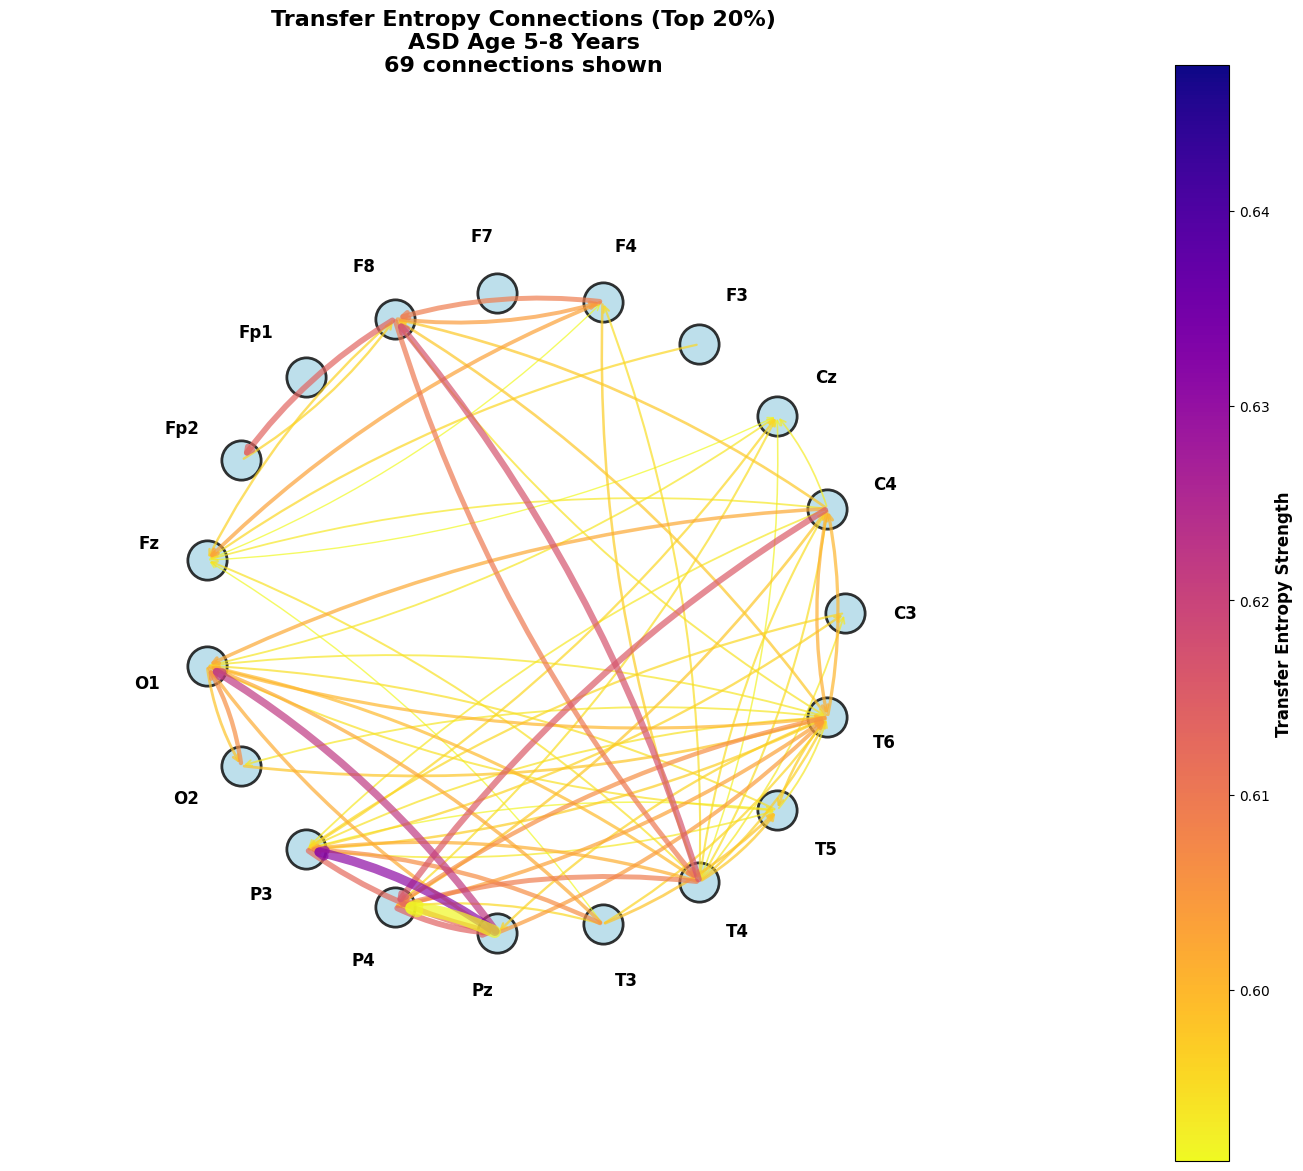

Creating chord plot with 15 connections and HUGE STRAIGHT arrows


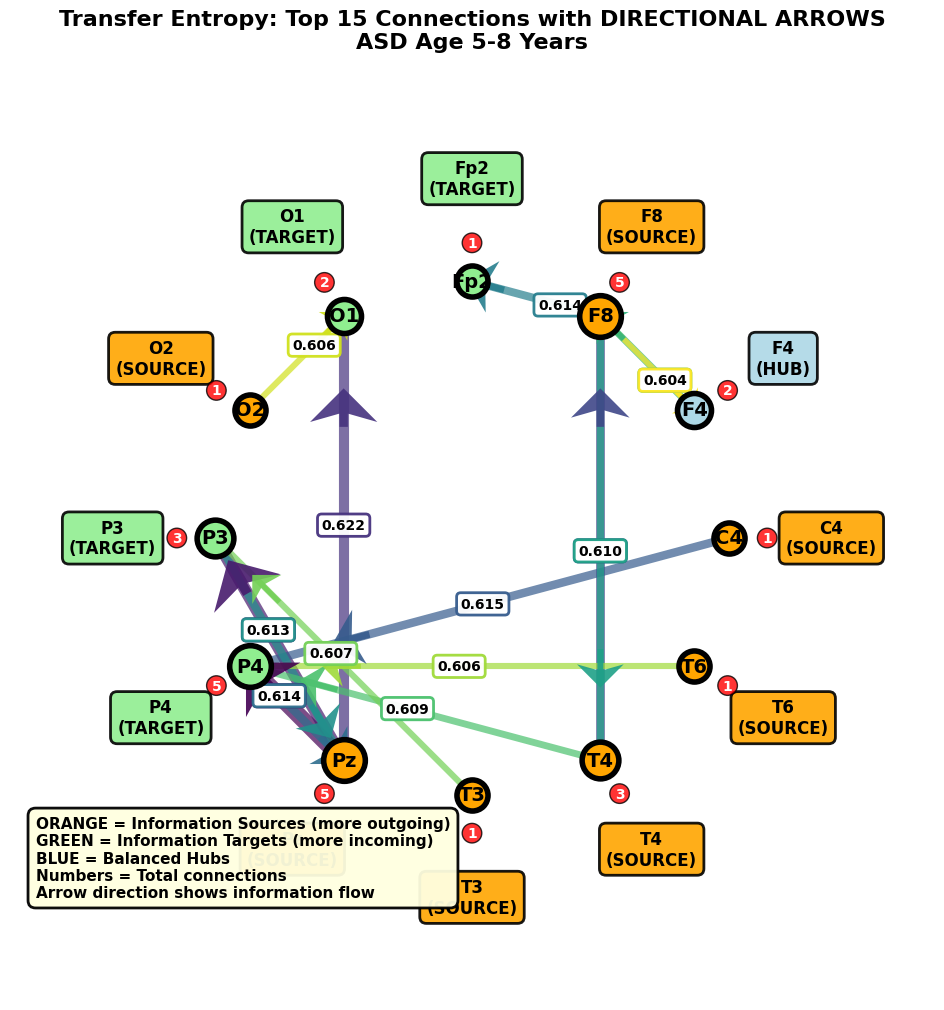

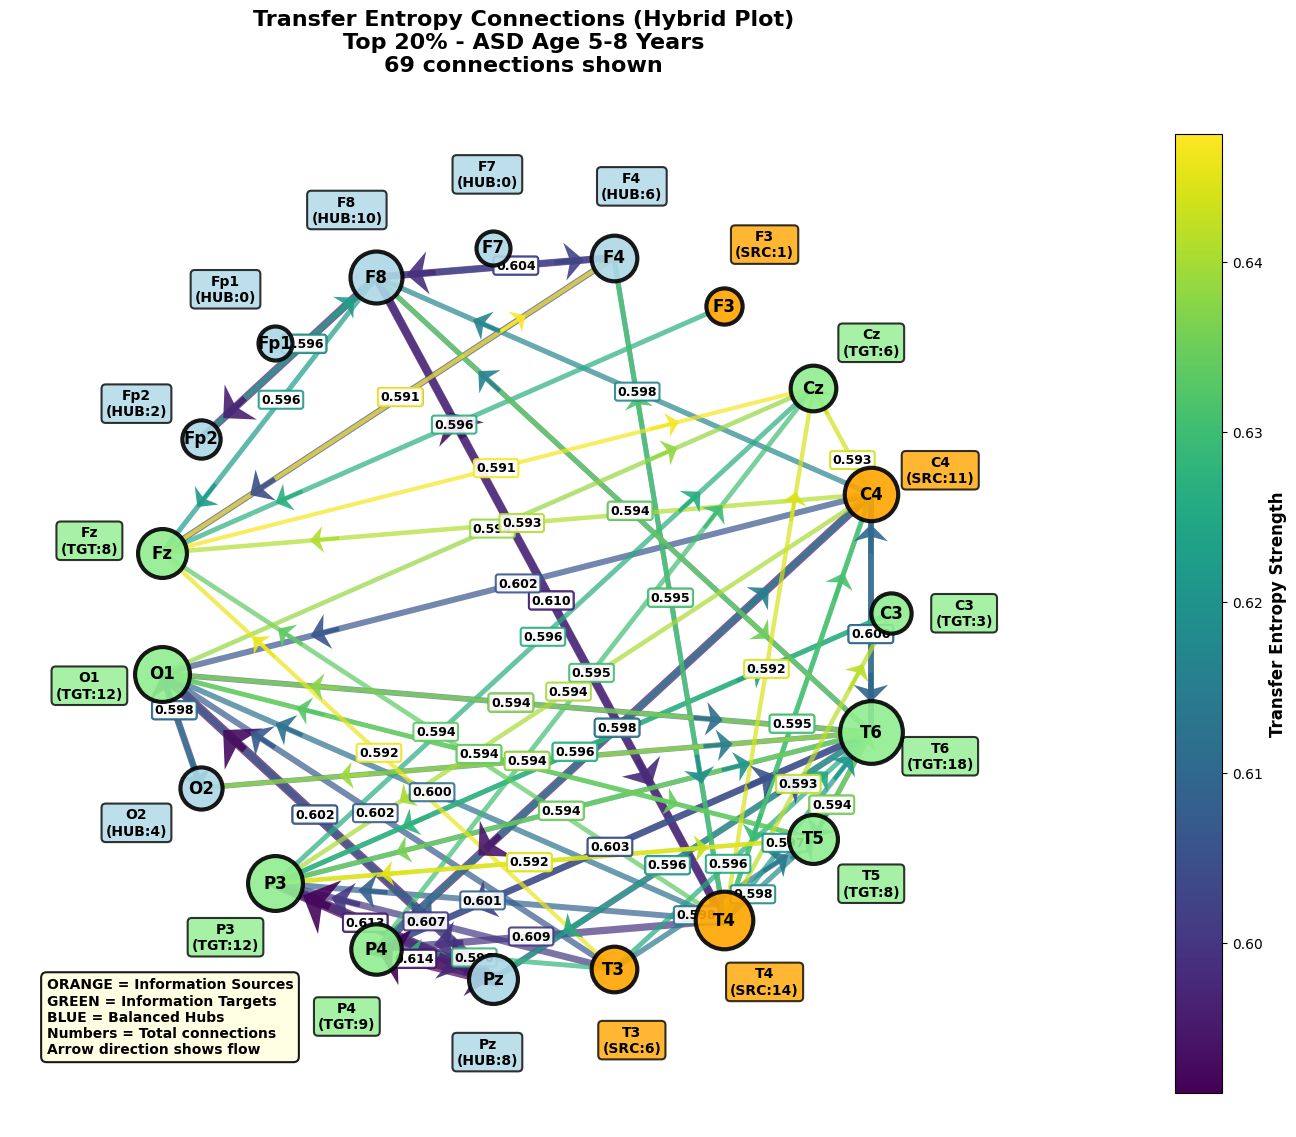


CIRCULAR PLOT ANALYSIS:
TOP INFORMATION SOURCES (outgoing):
   T4: 11 out, 3 in
   C4: 8 out, 3 in
   T6: 8 out, 10 in
   T3: 6 out, 0 in
   F8: 5 out, 5 in

TOP INFORMATION TARGETS (incoming):
   T6: 10 in, 8 out
   P3: 7 in, 5 out
   O1: 7 in, 5 out
   Fz: 6 in, 2 out
   Cz: 6 in, 0 out

TOP 10 STRONGEST CONNECTIONS:
 1.  Pz -> P4 : 0.6475
 2.  Pz -> P3 : 0.6311
 3.  Pz -> O1 : 0.6219
 4.  T4 -> F8 : 0.6168
 5.  C4 -> P4 : 0.6154
 6.  P4 -> Pz : 0.6139
 7.  F8 -> Fp2: 0.6136
 8.  P3 -> Pz : 0.6126
 9.  F8 -> T4 : 0.6098
10.  F4 -> F8 : 0.6092

CHORD PLOT ANALYSIS:
TOP INFORMATION SOURCES (outgoing):
   Pz: 3 out, 2 in
   F8: 3 out, 2 in
   T4: 2 out, 1 in
   C4: 1 out, 0 in
   P4: 1 out, 4 in

TOP INFORMATION TARGETS (incoming):
   P4: 4 in, 1 out
   P3: 2 in, 1 out
   O1: 2 in, 0 out
   F8: 2 in, 3 out
   Pz: 2 in, 3 out

TOP 10 STRONGEST CONNECTIONS:
 1.  Pz -> P4 : 0.6475
 2.  Pz -> P3 : 0.6311
 3.  Pz -> O1 : 0.6219
 4.  T4 -> F8 : 0.6168
 5.  C4 -> P4 : 0.6154
 6.  P4 -> Pz : 0

In [63]:
teFileAsd58 = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/transfer_entropy/transfer_entropy_results_58_asd.xlsx"
matrixDf = load_transfer_entropy_matrix(teFileAsd58)
print(f"\nTransfer entropy matrix loaded!")
print(f"Matrix dimensions: {matrixDf.shape}")
print(f"Electrodes: {matrixDf.index.tolist()}")

fig1, connections1 = create_te_circular_plot(matrixDf, thresholdPercentile=80, 
                                           titleSuffix="ASD Age 5-8 Years")
plt.show()

fig2, connections2 = create_chord_with_huge_straight_arrows(matrixDf, topN=15,
                                                          titleSuffix="ASD Age 5-8 Years")
plt.show()

fig3, connections3 = create_hybrid_circular_plot(matrixDf, thresholdPercentile=80,
                                                titleSuffix="ASD Age 5-8 Years")
plt.show()

analyze_connections(connections1, "Circular Plot")
analyze_connections(connections2, "Chord Plot") 
analyze_connections(connections3, "Hybrid Plot")

fig1.savefig("te_circular_plot.png", dpi=300, bbox_inches='tight', facecolor='white')
fig2.savefig("te_chord_huge_arrows.png", dpi=300, bbox_inches='tight', facecolor='white')
fig3.savefig("te_hybrid_plot.png", dpi=300, bbox_inches='tight', facecolor='white')

## Examples 

Actual TE range: 0.5912 - 0.6475
Color scale range: 0.5912 - 0.6475
Line width scale factor: 1.0
Actual TE range: 0.6021 - 0.6475
Color scale range: 0.6021 - 0.6475
Line width scale factor: 1.0
Actual TE range: 0.5948 - 0.6475
Color scale range: 0.5948 - 0.6475
Line width scale factor: 1.0
Actual TE range: 0.5019 - 0.6475
Color scale range: 0.5019 - 0.6475
Line width scale factor: 1.0


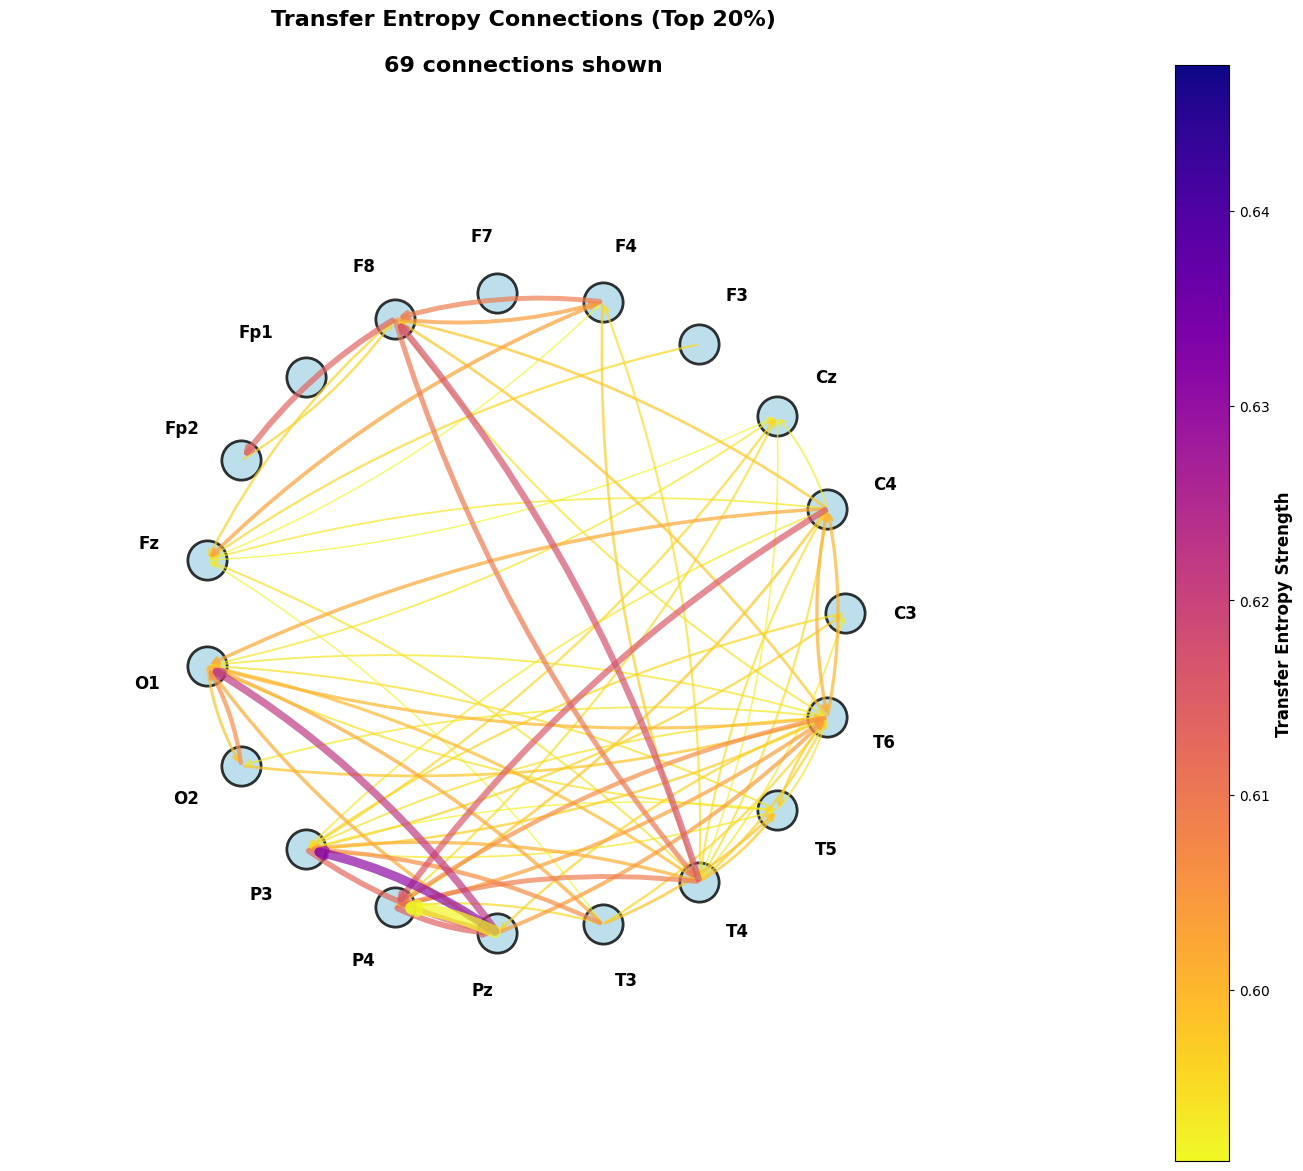

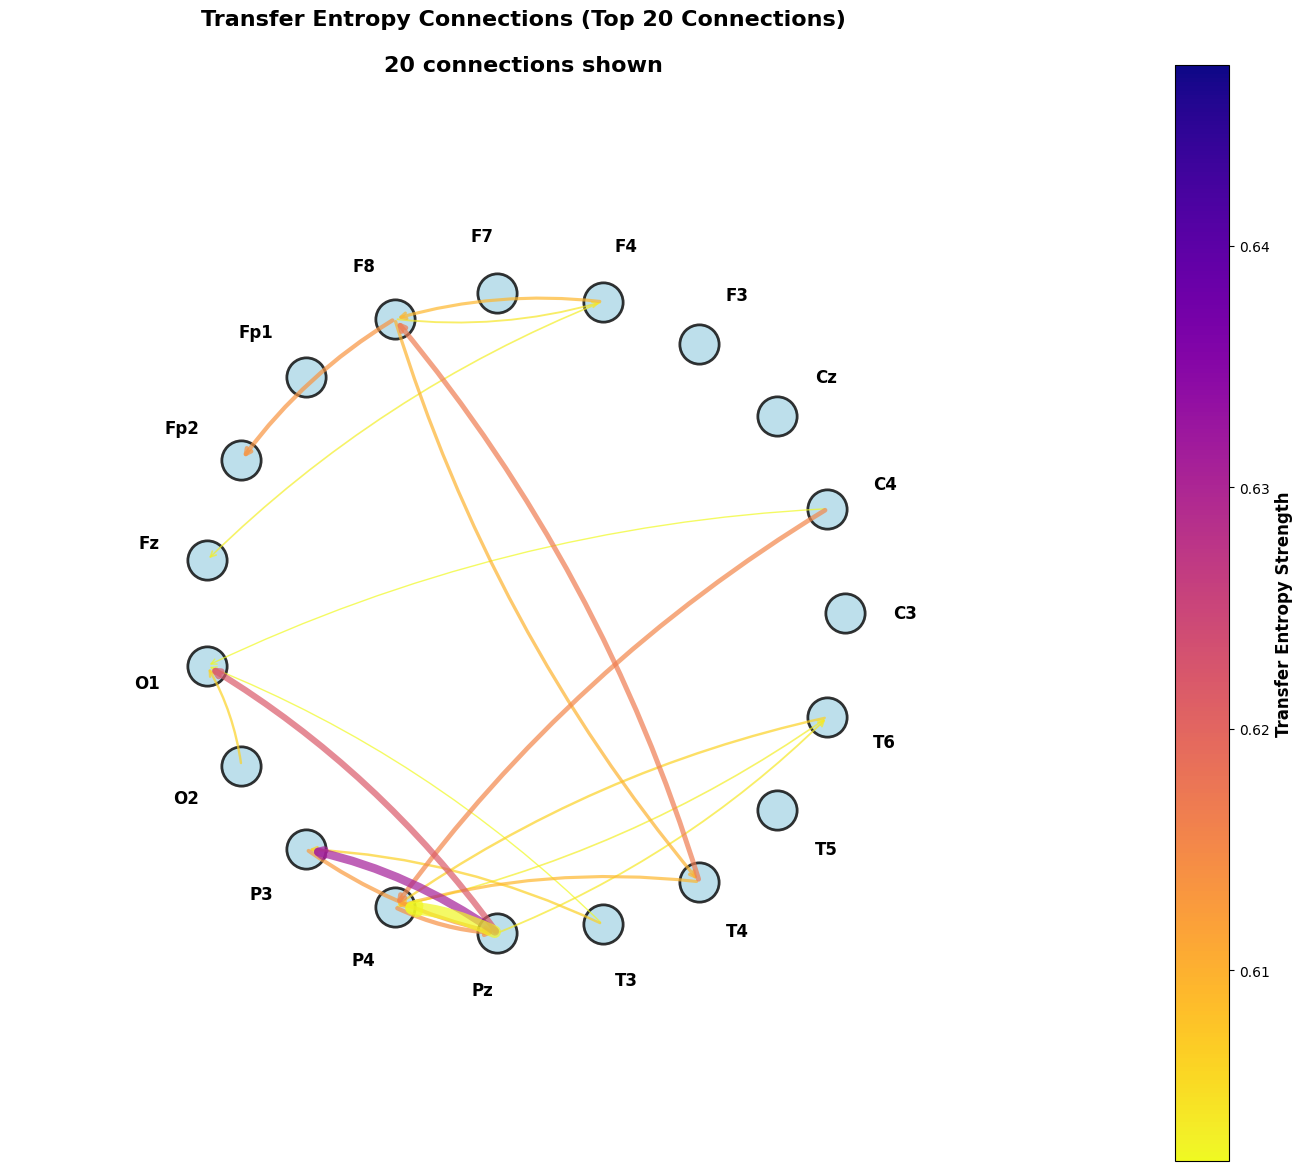

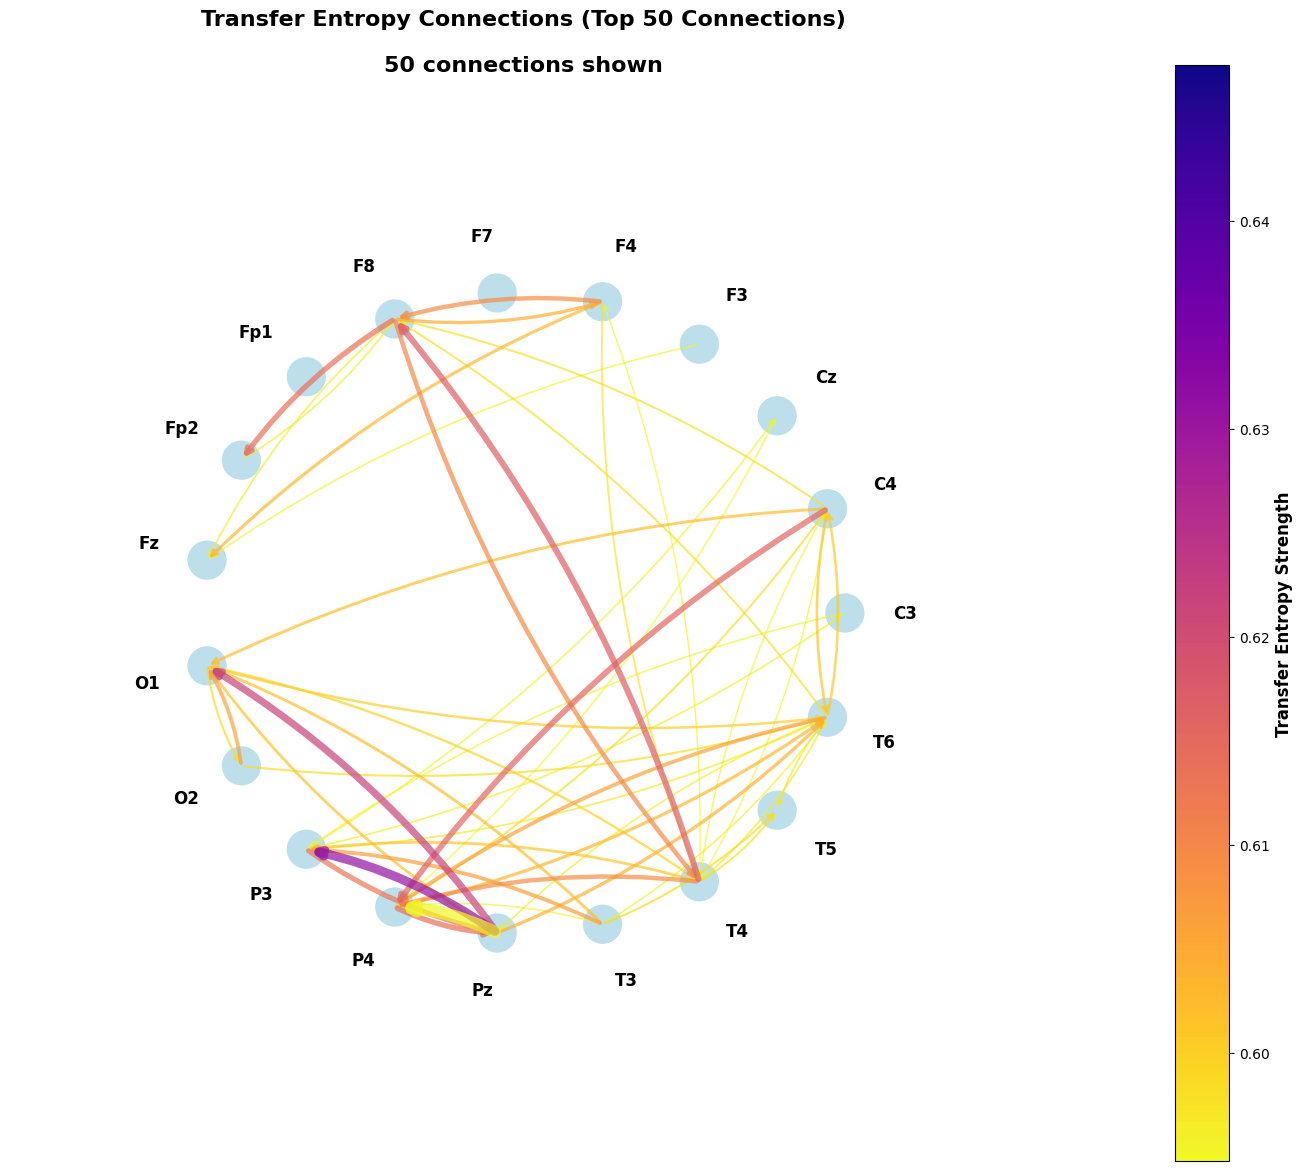

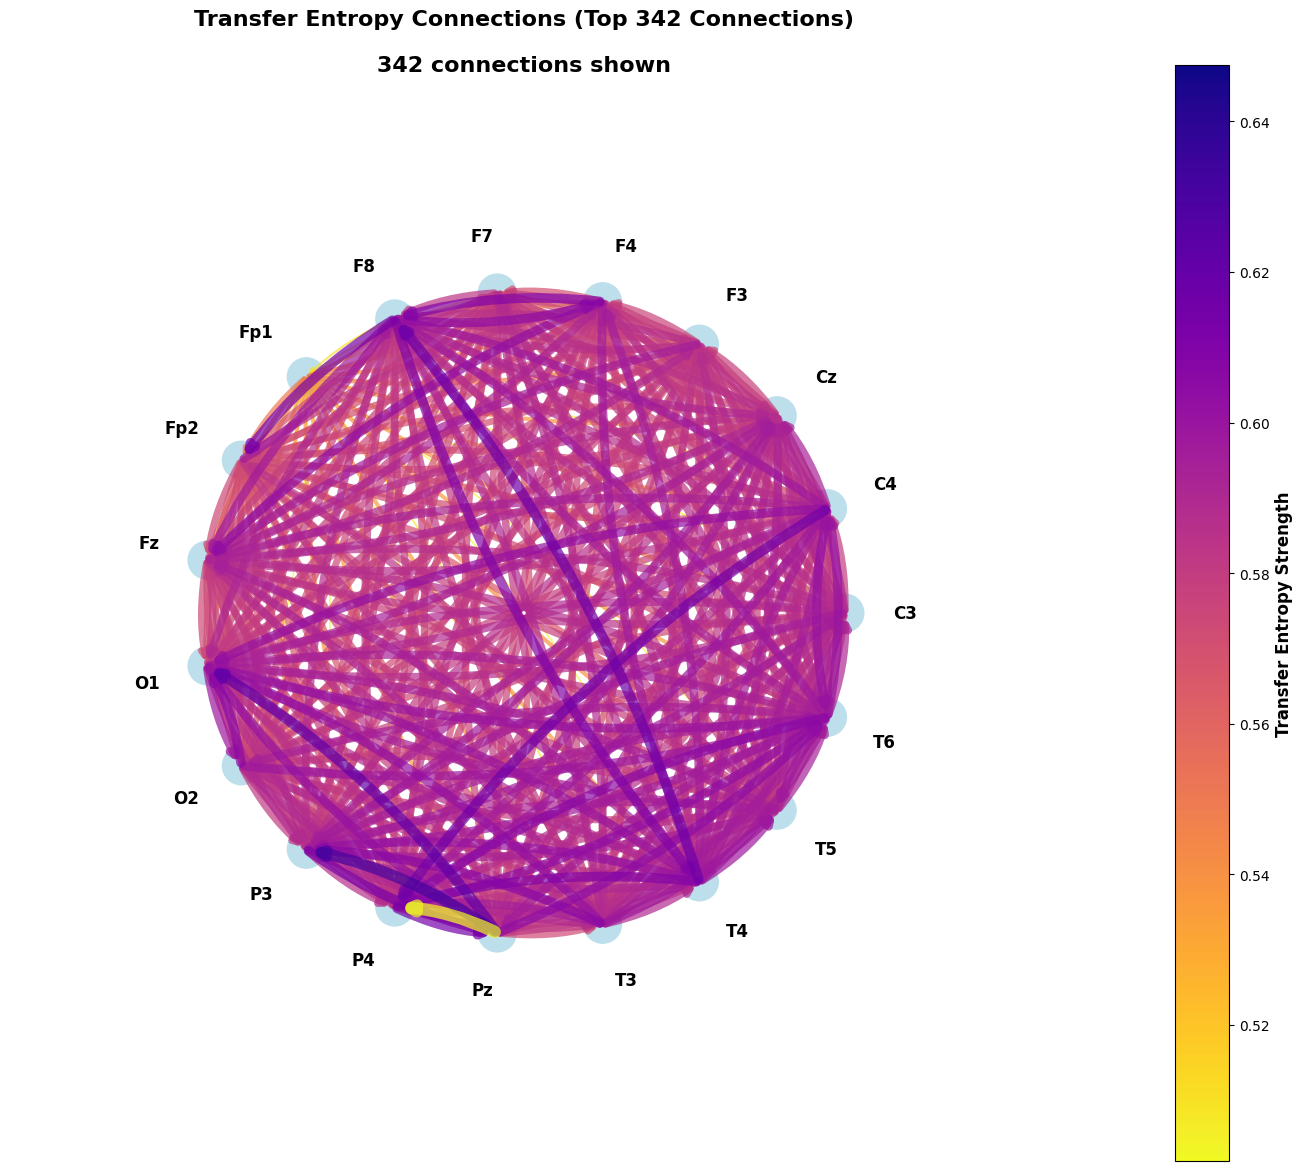

In [64]:
# Top 20% by percentile
fig1, conn1 = create_te_circular_plot(matrixDf, thresholdPercentile=80)

# Top 20 connections
fig2, conn2 = create_te_circular_plot(matrixDf, showTopN=20)

# Top 50 connections without node outlines
fig3, conn3 = create_te_circular_plot(matrixDf, showTopN=50, removeNodeOutline=True)

# Show all connections without outlines
fig4, conn4 = create_te_circular_plot(matrixDf, showTopN=342, removeNodeOutline=True)

Actual TE range: 0.5912 - 0.6475
Color scale range: 0.4500 - 0.7500
Line width scale factor: 1.0
Actual TE range: 0.6021 - 0.6475
Color scale range: 0.4500 - 0.7000
Line width scale factor: 1.0
Actual TE range: 0.5948 - 0.6475
Color scale range: 0.5948 - 0.6475
Line width scale factor: 1.0


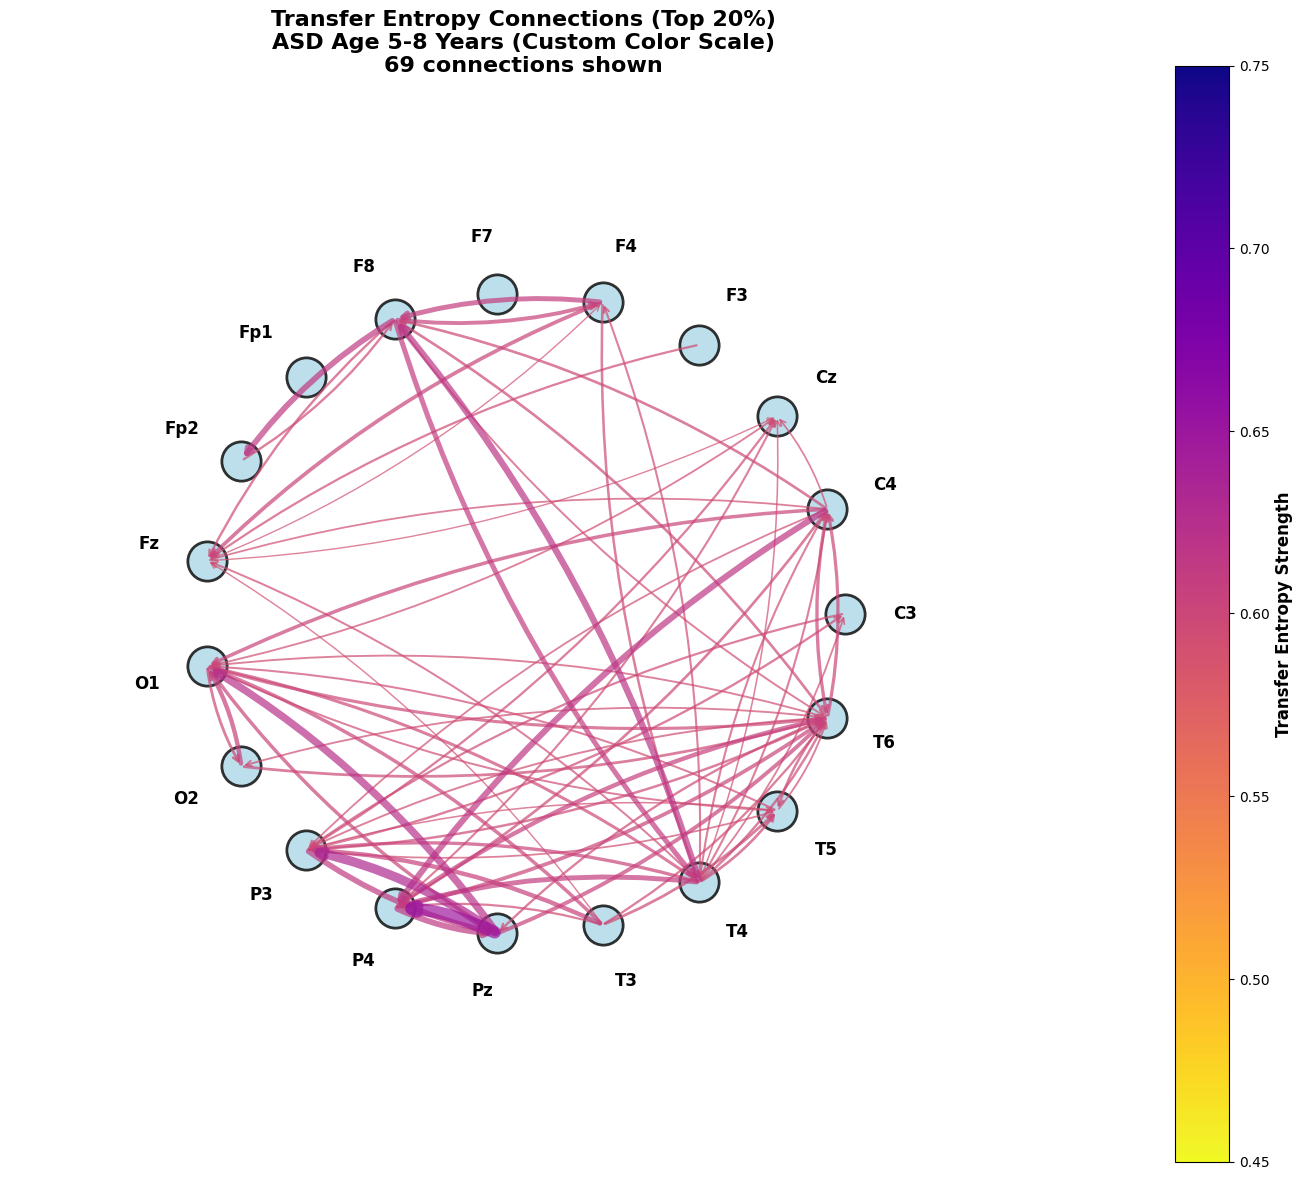

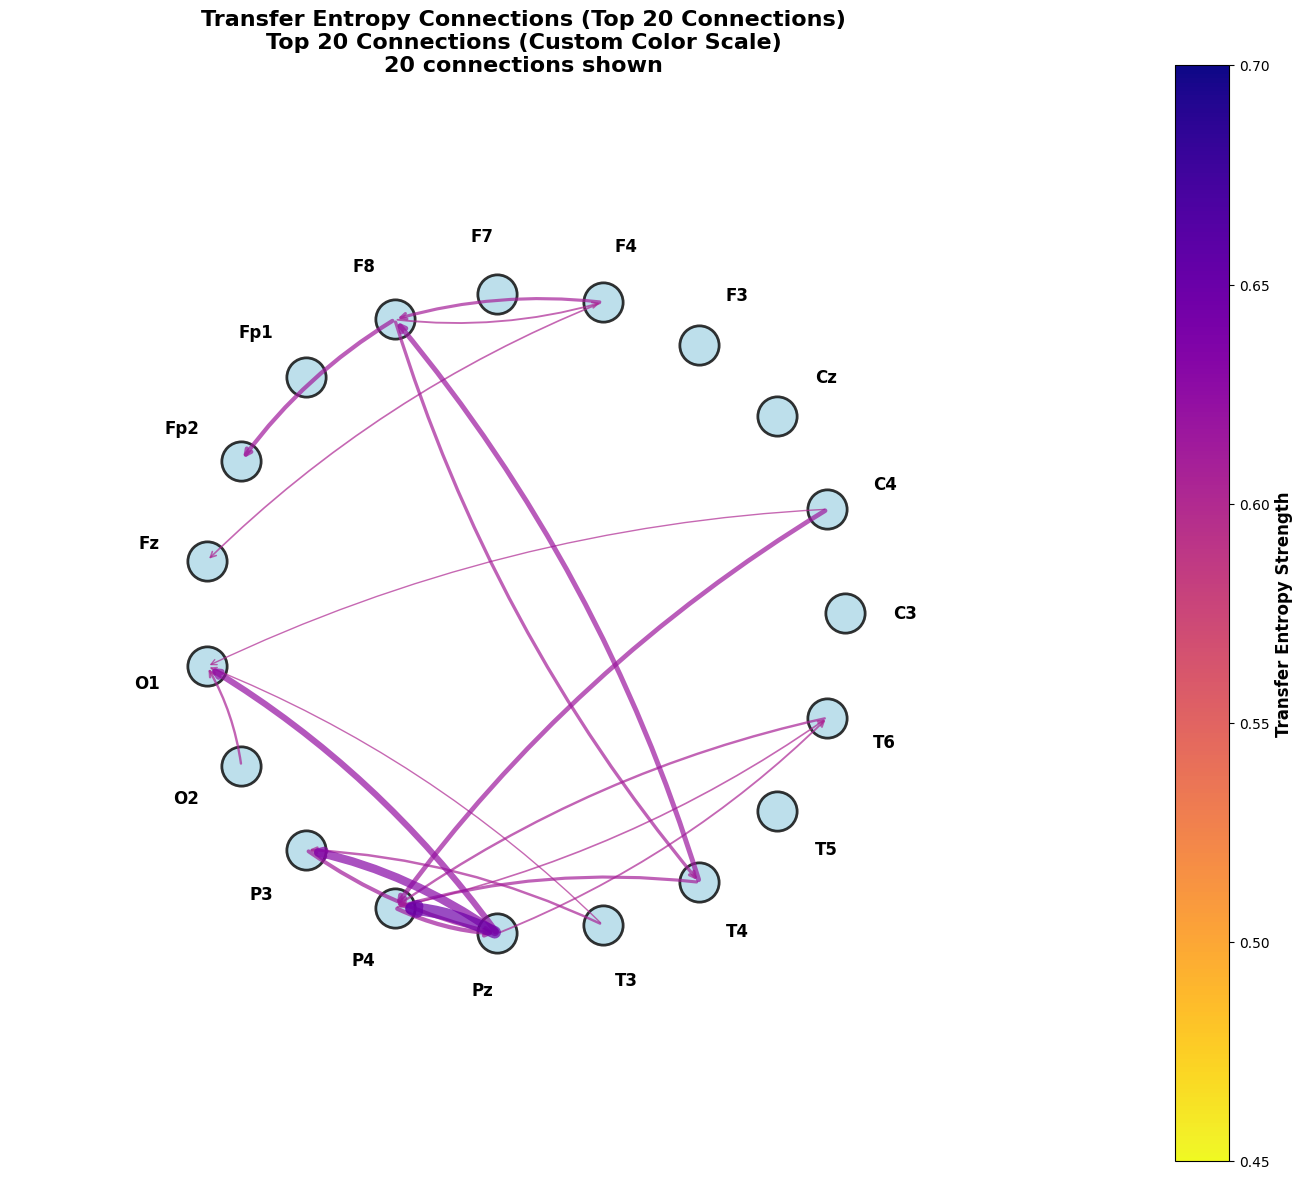

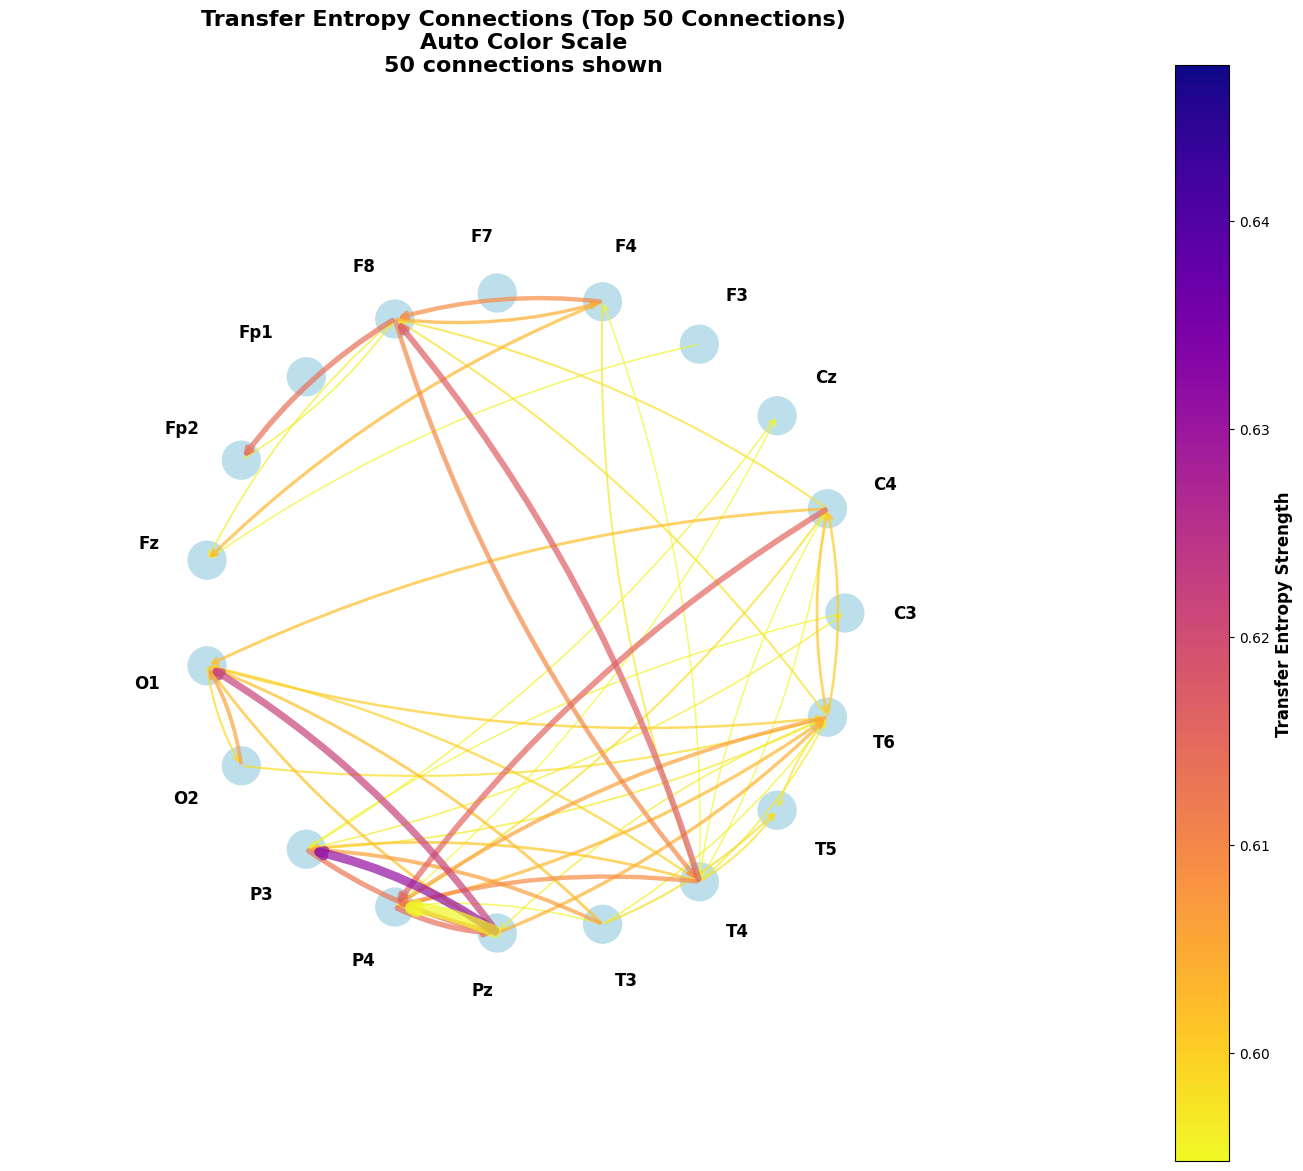

In [65]:
# Example usage with custom color scale from 0.45 to 0.75
fig1, conn1 = create_te_circular_plot(matrixDf, thresholdPercentile=80, 
                                     colorScaleMin=0.45, colorScaleMax=0.75,
                                     titleSuffix="ASD Age 5-8 Years (Custom Color Scale)")

# Top 20 connections with custom color scale
fig2, conn2 = create_te_circular_plot(matrixDf, showTopN=20, 
                                     colorScaleMin=0.45, colorScaleMax=0.7,
                                     titleSuffix="Top 20 Connections (Custom Color Scale)")

# Without color scale parameters (uses actual data range)
fig3, conn3 = create_te_circular_plot(matrixDf, showTopN=50, removeNodeOutline=True,
                                     titleSuffix="Auto Color Scale")

plt.show()

# Main Plot for Paper :))

Loaded data shape: (342, 5)
Columns: ['Pair name', 'TE list (without gaussian noise)', 'Avg TE (without gaussian noise)', 'TE list (with gaussian noise)', 'Avg TE (with gaussian noise)']
Found 19 unique electrodes: ['C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'P3', 'P4', 'Pz', 'T3', 'T4', 'T5', 'T6']
Matrix shape: (19, 19)
Non-zero values: 342
TE value range: 0.5027 - 0.6728

Transfer entropy matrix loaded!
Matrix dimensions: (19, 19)
Electrodes: ['C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'P3', 'P4', 'Pz', 'T3', 'T4', 'T5', 'T6']
Actual TE range: 0.5812 - 0.6728
Color scale range: 0.4000 - 0.7000
Line width scale factor: 1


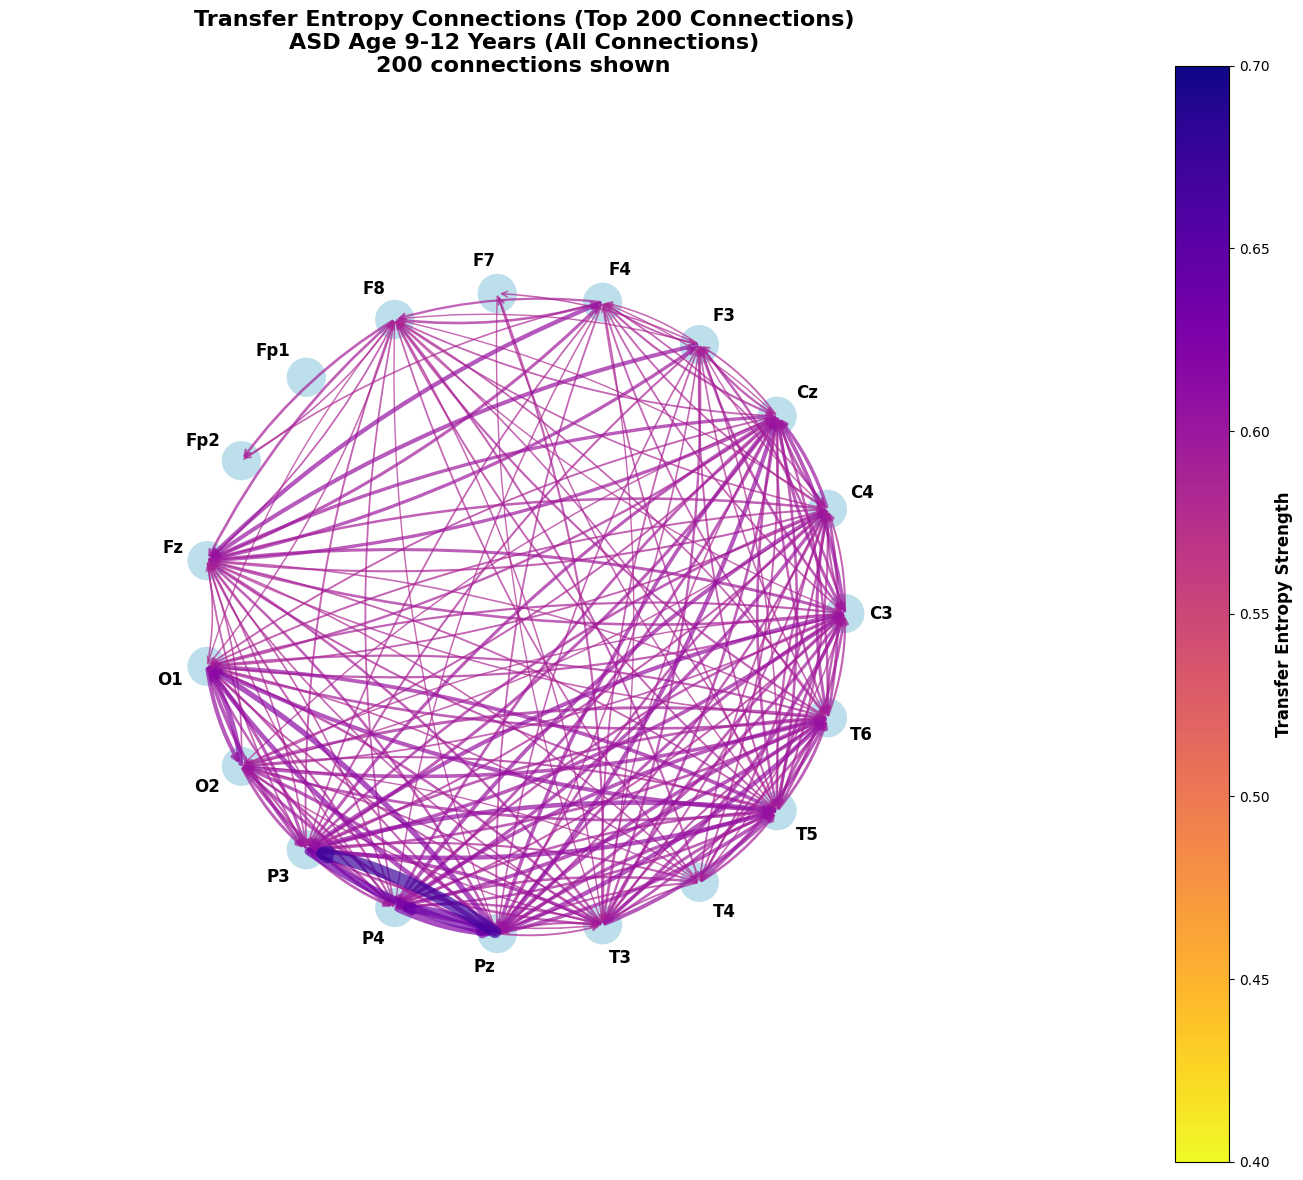

In [69]:
teFile = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/transfer_entropy/transfer_entropy_results_912_asd.xlsx"
matrixDf = load_transfer_entropy_matrix(teFile)
print(f"\nTransfer entropy matrix loaded!")
print(f"Matrix dimensions: {matrixDf.shape}")
print(f"Electrodes: {matrixDf.index.tolist()}")

fig1, conn2 = create_te_circular_plot(matrixDf, showTopN=200, 
                                     colorScaleMin=0.4, colorScaleMax=0.7, removeNodeOutline=True,
                                     labelDistance=1.075, lineWidthScale=1,
                                     titleSuffix="ASD Age 9-12 Years (All Connections)")

# fig1.savefig("te_circular_plot.png", dpi=800, bbox_inches='tight', facecolor='white')